## Installing Necessary Libraries

In [1]:
pip install pandas xgboost tensorflow matplotlib seaborn scikit-learn

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


## Importing Data

In [ ]:
import pandas as pd

# Load dataset
df = pd.read_csv("dataset.csv")

# Basic overview
print("Shape:", df.shape)
df.head()

Shape: (117298, 72)


,Date,Size,Qty,Amount,Fulfilment_Amazon,Fulfilment_Merchant,ship-service-level_Expedited,ship-service-level_Standard,Category_Blouse,Category_Bottom,...,B2B_False,B2B_True,Status_Cancelled,Status_Damaged,Status_Delivered,Status_Returned,Status_Shipped,month_April,month_June,month_May
0,2022-04-30,8,1,544.0,0,1,0,1,0,0,...,1,0,0,0,1,0,0,1,0,0
1,2022-04-30,2,1,1233.0,0,1,0,1,0,0,...,1,0,0,0,1,0,0,1,0,0
2,2022-04-30,3,1,1146.0,1,0,1,0,0,0,...,1,0,0,0,0,0,1,1,0,0
3,2022-04-30,5,1,999.0,1,0,1,0,0,0,...,1,0,0,0,0,0,1,1,0,0
4,2022-04-30,2,1,660.0,1,0,1,0,0,0,...,1,0,0,0,0,0,1,1,0,0


## Describing Data

In [3]:
# Data info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 117298 entries, 0 to 117297
Data columns (total 72 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Date                               117298 non-null  object 
 1   Size                               117298 non-null  object 
 2   Qty                                117298 non-null  int64  
 3   Amount                             110894 non-null  float64
 4   Fulfilment_Amazon                  117298 non-null  int64  
 5   Fulfilment_Merchant                117298 non-null  int64  
 6   ship-service-level_Expedited       117298 non-null  int64  
 7   ship-service-level_Standard        117298 non-null  int64  
 8   Category_Blouse                    117298 non-null  int64  
 9   Category_Bottom                    117298 non-null  int64  
 10  Category_Dupatta                   117298 non-null  int64  
 11  Category_Ethnic Dress              1172

In [4]:
# Summary statistics
df.describe()

,Qty,Amount,Fulfilment_Amazon,Fulfilment_Merchant,ship-service-level_Expedited,ship-service-level_Standard,Category_Blouse,Category_Bottom,Category_Dupatta,Category_Ethnic Dress,...,B2B_False,B2B_True,Status_Cancelled,Status_Damaged,Status_Delivered,Status_Returned,Status_Shipped,month_April,month_June,month_May
count,117298.00000,110894.000000,117298.000000,117298.000000,117298.000000,117298.000000,117298.000000,117298.000000,117298.000000,117298.000000,...,117298.000000,117298.000000,117298.000000,117298.000000,117298.000000,117298.000000,117298.000000,117298.000000,117298.000000,117298.000000
mean,0.90918,652.106976,0.685706,0.314294,0.676900,0.323100,0.007639,0.003589,0.000017,0.009727,...,0.992668,0.007332,0.138579,0.007681,0.237839,0.017843,0.598058,0.377423,0.297413,0.325163
std,0.30897,284.875616,0.464236,0.464236,0.467663,0.467663,0.087065,0.059802,0.004129,0.098147,...,0.085312,0.085312,0.345508,0.087306,0.425762,0.132383,0.490292,0.484744,0.457122,0.468438
min,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.00000,455.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.00000,612.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
75%,1.00000,788.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
max,15.00000,5584.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [5]:
# Missing values
df.isnull().sum()

Date                    0
Size                    0
Qty                     0
Amount               6404
Fulfilment_Amazon       0
                     ... 
Status_Returned         0
Status_Shipped          0
month_April             0
month_June              0
month_May               0
Length: 72, dtype: int64

## Exploratory Data Analysis (EDA)

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

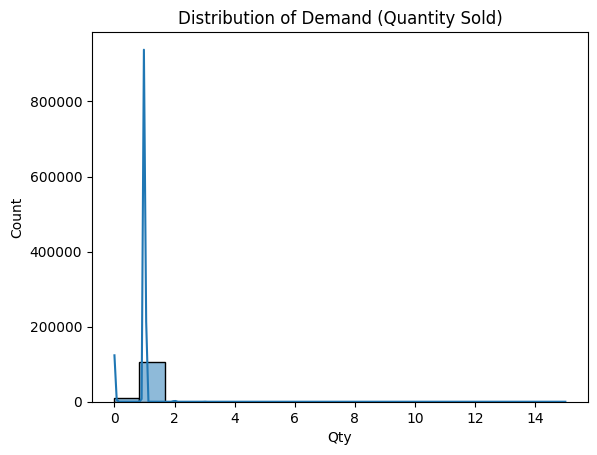

In [7]:
sns.histplot(df['Qty'], kde=True)
plt.title("Distribution of Demand (Quantity Sold)")
plt.show()

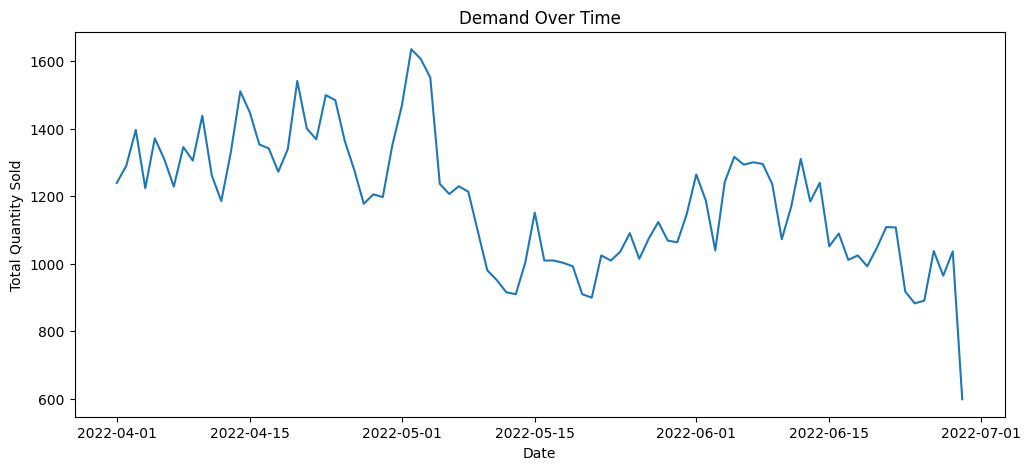

In [8]:
df['Date'] = pd.to_datetime(df['Date'])

df_grouped = df.groupby('Date')['Qty'].sum()

plt.figure(figsize=(12,5))
plt.plot(df_grouped)
plt.title("Demand Over Time")
plt.xlabel("Date")
plt.ylabel("Total Quantity Sold")
plt.show()

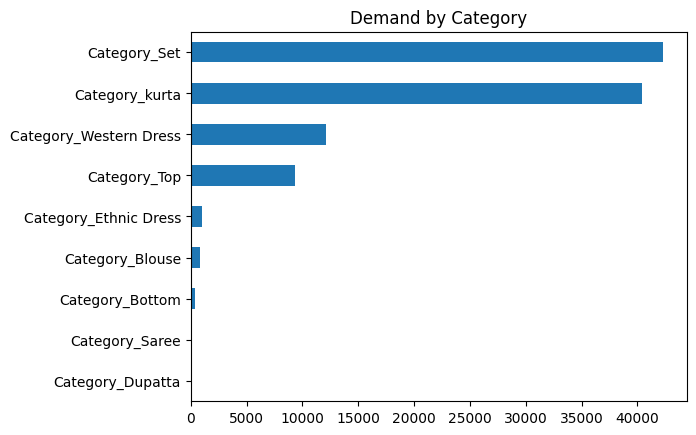

In [9]:
category_cols = [col for col in df.columns if "Category_" in col]
category_demand = df[category_cols].multiply(df['Qty'], axis=0).sum()
category_demand.sort_values().plot(kind='barh', title="Demand by Category")
plt.show()

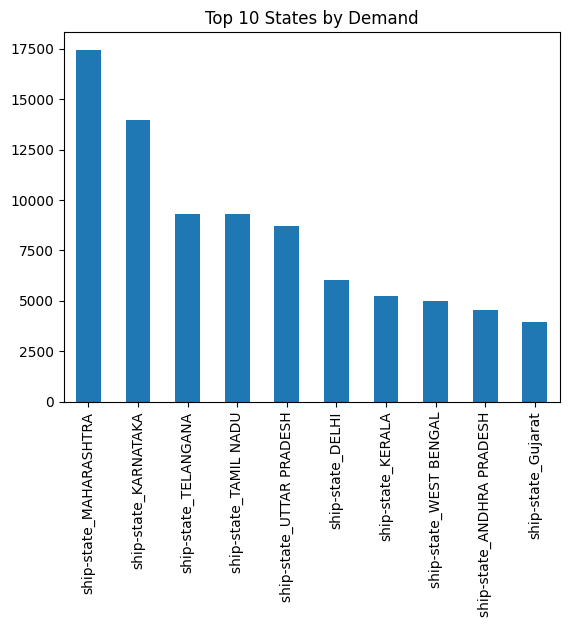

In [10]:
state_cols = [col for col in df.columns if "ship-state_" in col]
state_demand = df[state_cols].multiply(df['Qty'], axis=0).sum()
state_demand.sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top 10 States by Demand")
plt.show()

## Preprocessing: Drop Unnecessary Column and filling null values

In [11]:
df.fillna(0, inplace=True)

In [12]:
df = df.drop(['Date'], axis=1)

In [13]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Size'] = le.fit_transform(df['Size'])

## Model Pipeline

In [14]:
# Target = Demand
y = df['Qty']
# Drop target + unnecessary column
X = df.drop(['Qty'], axis=1)

In [15]:
# splitting data for training and testing
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [17]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
import numpy as np

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mape_rf = mean_absolute_percentage_error(y_test, y_pred_rf)

print("Random Forest RMSE:", rmse_rf)
print("Random Forest MAPE:", mape_rf)

Random Forest RMSE: 0.10264148862262701
Random Forest MAPE: 0.0023349421507733526


In [ ]:
def safe_mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask]))

In [35]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
mape_xgb = safe_mape(y_test, y_pred_xgb)

print("XGBoost RMSE:", rmse_xgb)
print("XGBoost MAPE:", mape_xgb)

XGBoost RMSE: 0.10237995701154971
XGBoost MAPE: 0.004256371027527541


In [19]:
import tensorflow as tf

model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1)
])

model.compile(optimizer='adam', loss='mse')

/Users/yashjain/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/yashjain/Library/Python/3.9/lib/python/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [20]:
history = model.fit(
    X_train_scaled, y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/30
2346/2346 ━━━━━━━━━━━━━━━━━━━━ 1s 324us/step - loss: 0.0961 - val_loss: 0.0296
Epoch 2/30
2346/2346 ━━━━━━━━━━━━━━━━━━━━ 1s 299us/step - loss: 0.0912 - val_loss: 0.0170
Epoch 3/30
2346/2346 ━━━━━━━━━━━━━━━━━━━━ 1s 301us/step - loss: 0.0197 - val_loss: 0.0147
Epoch 4/30
2346/2346 ━━━━━━━━━━━━━━━━━━━━ 1s 297us/step - loss: 0.0270 - val_loss: 0.0422
Epoch 5/30
2346/2346 ━━━━━━━━━━━━━━━━━━━━ 1s 304us/step - loss: 0.0840 - val_loss: 0.0214
Epoch 6/30
2346/2346 ━━━━━━━━━━━━━━━━━━━━ 1s 298us/step - loss: 0.0053 - val_loss: 0.1144
Epoch 7/30
2346/2346 ━━━━━━━━━━━━━━━━━━━━ 1s 297us/step - loss: 0.0359 - val_loss: 0.0370
Epoch 8/30
2346/2346 ━━━━━━━━━━━━━━━━━━━━ 1s 300us/step - loss: 0.0145 - val_loss: 0.0221
Epoch 9/30
2346/2346 ━━━━━━━━━━━━━━━━━━━━ 1s 300us/step - loss: 0.0076 - val_loss: 0.0160
Epoch 10/30
2346/2346 ━━━━━━━━━━━━━━━━━━━━ 1s 297us/step - loss: 0.0073 - val_loss: 0.1115
Epoch 11/30
2346/2346 ━━━━━━━━━━━━━━━━━━━━ 1s 300us/step - loss: 0.0101 - val_loss: 0.0126
Epoch 12

In [21]:
y_pred_nn = model.predict(X_test_scaled)

734/734 ━━━━━━━━━━━━━━━━━━━━ 0s 180us/step


In [34]:
rmse_nn = np.sqrt(mean_squared_error(y_test, y_pred_nn))
mape_nn = safe_mape(y_test, y_pred_nn)

print("Neural Network RMSE:", rmse_nn)
print("Neural Network MAPE:", mape_nn)

Neural Network RMSE: 0.10617514104921347
Neural Network MAPE: 0.008455438744047724


In [30]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost", "Neural Network"],
    "RMSE": [rmse_rf, rmse_xgb, rmse_nn],
    "MAPE": [mape_rf, mape_xgb, mape_nn]
})

results

,Model,RMSE,MAPE
0,Random Forest,0.102641,0.002335
1,XGBoost,0.102380,0.004256
2,Neural Network,0.106175,0.008455


## Visualizing Prediction Results

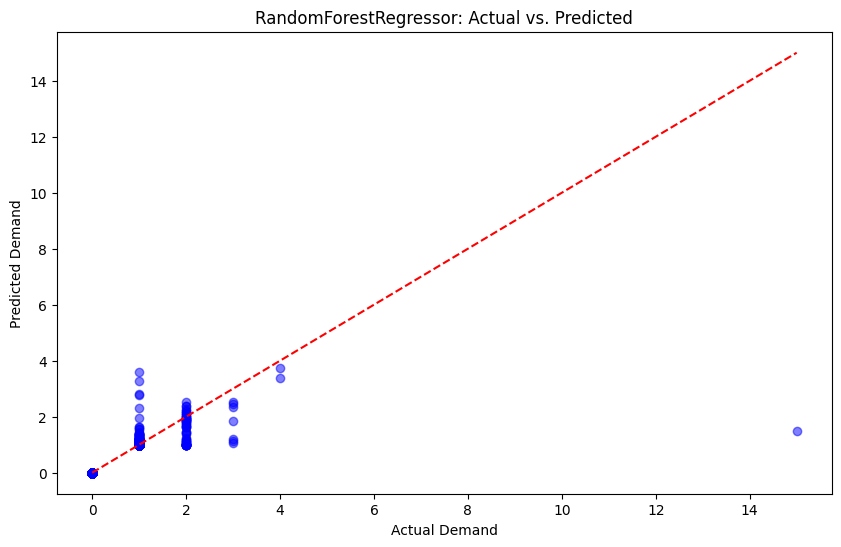

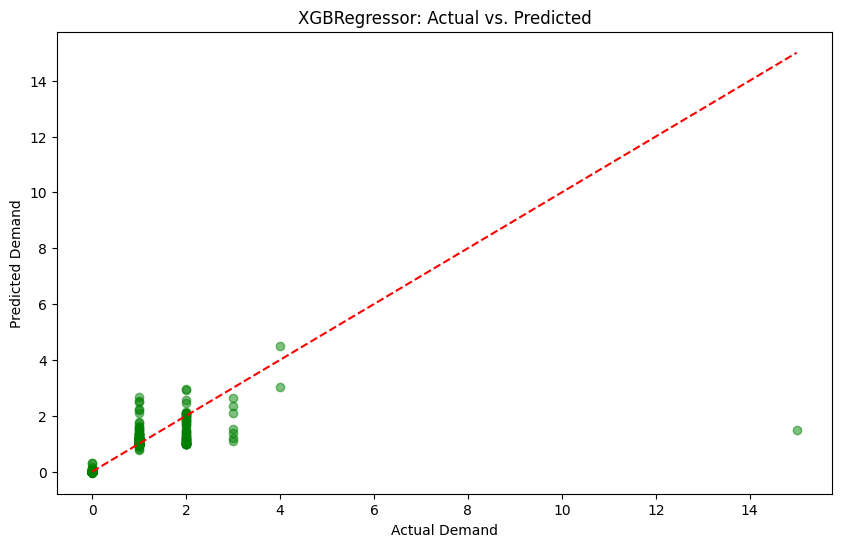

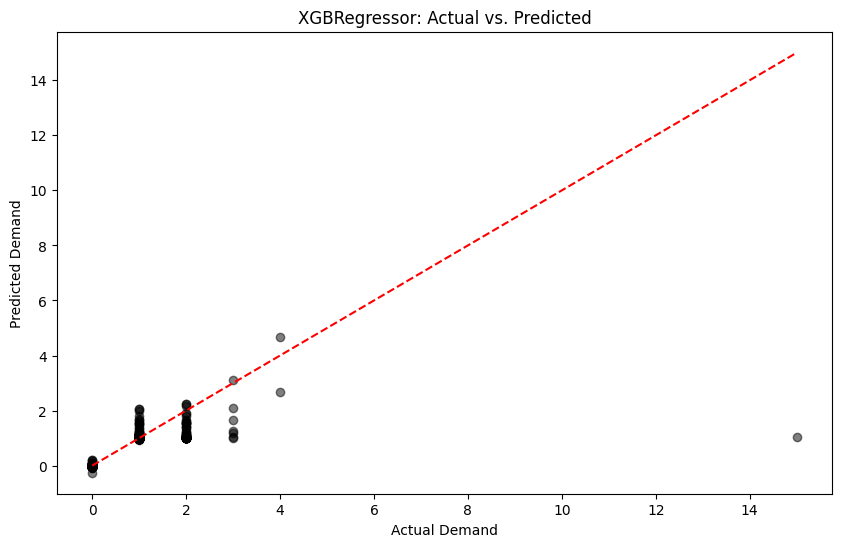

In [31]:
import matplotlib.pyplot as plt

# Visualizing RandomForestRegressor predictions
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_rf, color='blue', alpha=0.5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')
plt.title('RandomForestRegressor: Actual vs. Predicted')
plt.xlabel('Actual Demand')
plt.ylabel('Predicted Demand')
plt.show()

# Visualizing XGBRegressor predictions
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_xgb, color='green', alpha=0.5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')
plt.title('XGBRegressor: Actual vs. Predicted')
plt.xlabel('Actual Demand')
plt.ylabel('Predicted Demand')
plt.show()

# Visualizing Neural Network predictions
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_nn, color='black', alpha=0.5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')
plt.title('XGBRegressor: Actual vs. Predicted')
plt.xlabel('Actual Demand')
plt.ylabel('Predicted Demand')
plt.show()

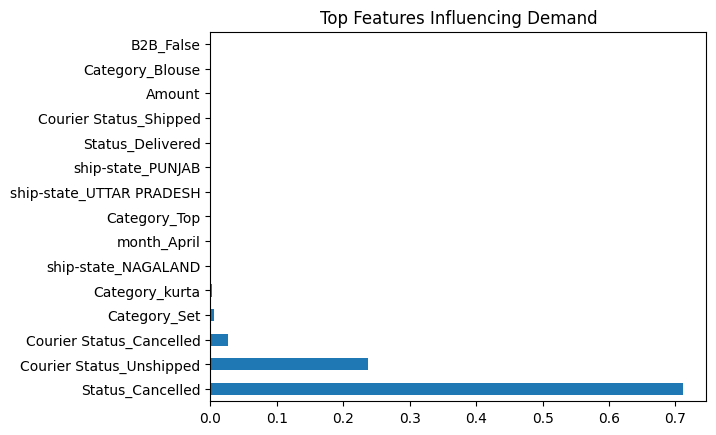

In [32]:
import pandas as pd

feat_imp = pd.Series(xgb.feature_importances_, index=X.columns)
feat_imp.sort_values(ascending=False).head(15).plot(kind='barh')
plt.title("Top Features Influencing Demand")
plt.show()

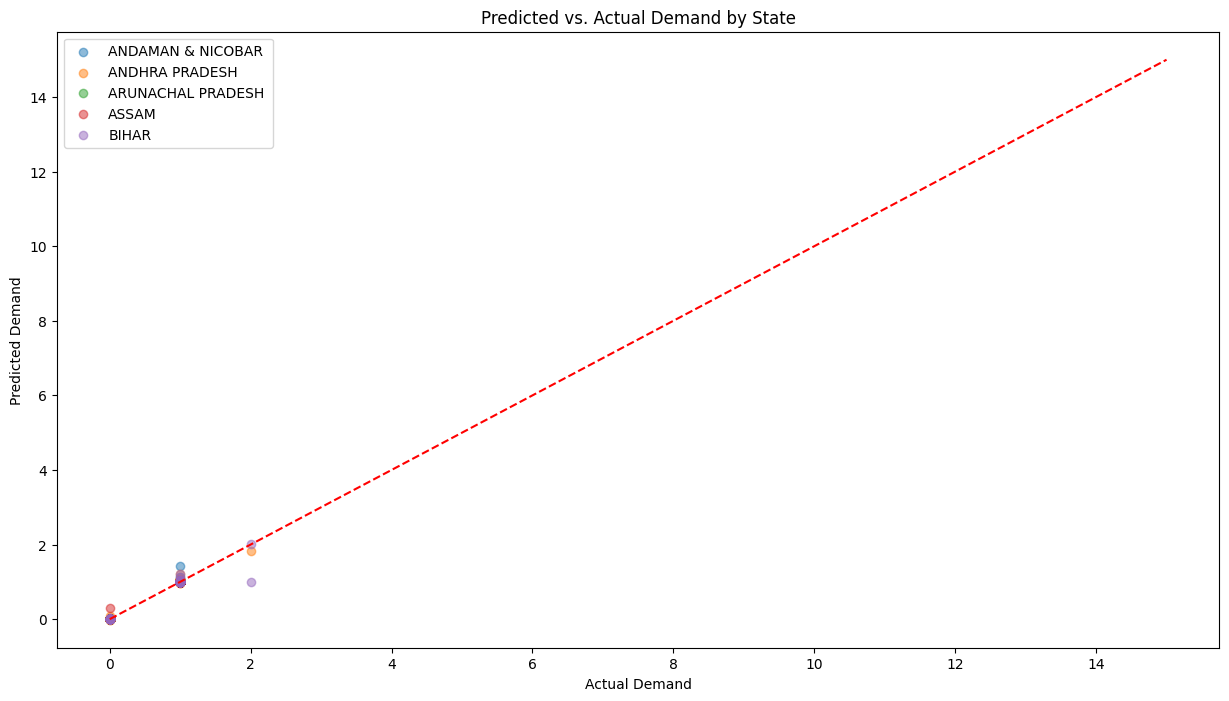

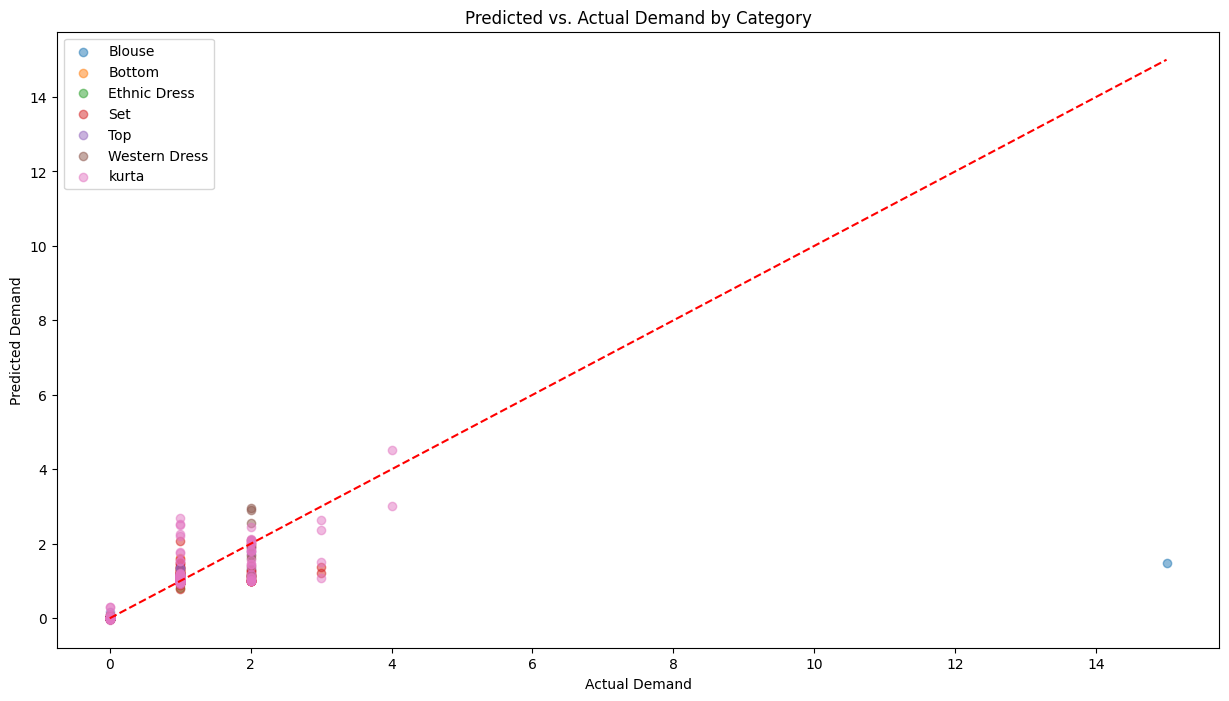

In [33]:
# Function to visualize predicted vs actual demand for each state
def visualize_by_state(predictions, actual, states):
    plt.figure(figsize=(15, 8))
    for state in states:
        idx = (X_test[f'ship-state_{state}'] == 1) & (~np.isnan(predictions)) & (~np.isnan(actual))
        plt.scatter(actual[idx], predictions[idx], label=state, alpha=0.5)
    plt.plot([min(actual), max(actual)], [min(actual), max(actual)], color='red', linestyle='--')
    plt.title('Predicted vs. Actual Demand by State')
    plt.xlabel('Actual Demand')
    plt.ylabel('Predicted Demand')
    plt.legend()
    plt.show()

# Function to visualize predicted vs actual demand for each category
def visualize_by_category(predictions, actual, categories):
    plt.figure(figsize=(15, 8))
    for category in categories:
        idx = (X_test[f'Category_{category}'] == 1) & (~np.isnan(predictions)) & (~np.isnan(actual))
        plt.scatter(actual[idx], predictions[idx], label=category, alpha=0.5)
    plt.plot([min(actual), max(actual)], [min(actual), max(actual)], color='red', linestyle='--')
    plt.title('Predicted vs. Actual Demand by Category')
    plt.xlabel('Actual Demand')
    plt.ylabel('Predicted Demand')
    plt.legend()
    plt.show()

# Visualizing by state
visualize_by_state(y_pred_xgb, y_test, ['ANDAMAN & NICOBAR ', 'ANDHRA PRADESH', 'ARUNACHAL PRADESH', 'ASSAM', 'BIHAR'])

# Visualizing by category
visualize_by_category(y_pred_xgb, y_test, ['Blouse', 'Bottom', 'Ethnic Dress', 'Set', 'Top', 'Western Dress', 'kurta'])